# TP1 – Visión Computacional Avanzada
## Aprendizaje Contrastivo y Continual Learning en CIFAR-10

Este notebook es el **entry-point** del trabajo práctico. Está organizado en 4 etapas:

| Etapa | Descripción |
|-------|-------------|
| 1 | Dataset: división de CIFAR-10 en 5 tareas, replay buffer |
| 2 | Pre-entrenamiento contrastivo (SupCon) sobre Tarea 0 |
| 3 | Métodos CL: Fine-tuning, EWC, LwF, Co²L |
| 4 | Comparación y análisis |

> **Antes de empezar**: ejecutar `python scripts/download_data.py` desde la raíz del repositorio para descargar CIFAR-10.

---
## Configuración general

In [5]:
import sys
from pathlib import Path

# Ensure the repo root is in sys.path so modules are importable.
repo_root = Path().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_ROOT = repo_root / 'data' / 'cifar10'
IMGS_DIR  = repo_root / 'imgs'
IMGS_DIR.mkdir(exist_ok=True)

print(f'Device  : {DEVICE}')
print(f'Data    : {DATA_ROOT}')
print(f'Images  : {IMGS_DIR}')

Device  : cuda
Data    : /home/tiziano/Documents/udesa/5to/tp1_vision_artificial_avanzada/data/cifar10
Images  : /home/tiziano/Documents/udesa/5to/tp1_vision_artificial_avanzada/imgs


---
## Etapa 1 – Dataset y Replay Buffer

In [6]:
from data.cifar10_tasks import CIFAR10Tasks, TASK_CLASSES, CIFAR10_CLASSES, NUM_TASKS

tasks = CIFAR10Tasks(data_root=DATA_ROOT, contrastive=False, download=True)

print(f'Number of tasks     : {tasks.num_tasks}')
print(f'Classes per task    : {tasks.classes_per_task}')
print(f'Total classes       : {tasks.total_classes}')
print()
for t in range(NUM_TASKS):
    class_names = [CIFAR10_CLASSES[c] for c in TASK_CLASSES[t]]
    n_train = len(tasks.get_train(t))
    n_test  = len(tasks.get_test(t))
    print(f'  Task {t}: {class_names}  |  train={n_train}  test={n_test}')

Number of tasks     : 5
Classes per task    : 2
Total classes       : 10

  Task 0: ['airplane', 'automobile']  |  train=10000  test=2000
  Task 1: ['bird', 'cat']  |  train=10000  test=2000
  Task 2: ['deer', 'dog']  |  train=10000  test=2000
  Task 3: ['frog', 'horse']  |  train=10000  test=2000
  Task 4: ['ship', 'truck']  |  train=10000  test=2000


In [7]:
from data.replay_buffer import ReplayBuffer
from torch.utils.data import DataLoader

# Demostración del replay buffer con capacidad reducida.
buffer = ReplayBuffer(capacity=500, seed=42)

for task_id in range(NUM_TASKS):
    loader = DataLoader(tasks.get_train(task_id), batch_size=128, shuffle=True)
    buffer.add_from_loader(loader, task_id=task_id)
    print(f'After Task {task_id}: {buffer}')

After Task 0: ReplayBuffer(capacity=500, stored=500, seen=10000)
After Task 1: ReplayBuffer(capacity=500, stored=500, seen=20000)
After Task 2: ReplayBuffer(capacity=500, stored=500, seen=30000)
After Task 3: ReplayBuffer(capacity=500, stored=500, seen=40000)
After Task 4: ReplayBuffer(capacity=500, stored=500, seen=50000)


---
## Etapa 2 – Pre-entrenamiento Contrastivo (SupCon)

In [10]:
from models.backbone       import ResNet18Backbone
from models.projection_head import ProjectionHead
from models.linear_head    import LinearHead
from training.contrastive_trainer import ContrastiveTrainer

# --- Backbone + projection head ---
backbone  = ResNet18Backbone(pretrained=False, cifar_stem=True).to(DEVICE)
proj_head = ProjectionHead(in_dim=512, hidden_dim=512, out_dim=128).to(DEVICE)

# Two-view DataLoader for contrastive training on Task 0.
tasks_contrastive = CIFAR10Tasks(data_root=DATA_ROOT, contrastive=True)
task0_train = DataLoader(
    tasks_contrastive.get_train(0),
    batch_size=256, shuffle=True, num_workers=2, pin_memory=True, drop_last=True
)

trainer = ContrastiveTrainer(backbone, proj_head, device=DEVICE, temperature=0.07)

# NOTE: For a full run use epochs=200.  Set to a small value for quick testing.
EPOCHS_CONTRASTIVE = 5  # <-- increase to 200 for actual training

loss_history = trainer.train(task0_train, epochs=EPOCHS_CONTRASTIVE, lr=0.05)

  [ContrastiveTrainer] Epoch 1/5 | SupCon Loss: nan


/tmp/ipykernel_465603/1233519305.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


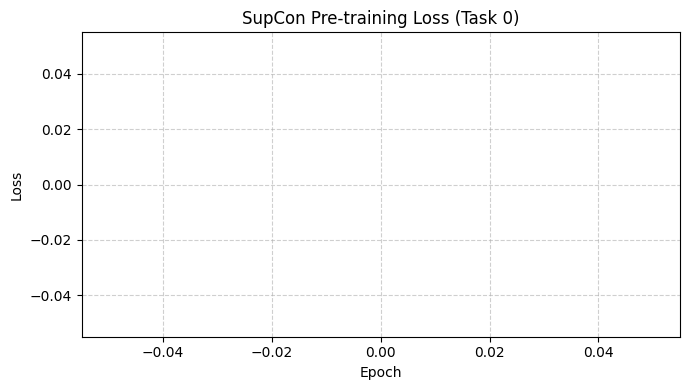

In [11]:
from evaluation.visualization import plot_loss_curve

fig = plot_loss_curve(
    loss_history,
    title='SupCon Pre-training Loss (Task 0)',
    save_path=str(IMGS_DIR / 'supcon_loss.png')
)
fig.show()

/tmp/ipykernel_465603/1999876915.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


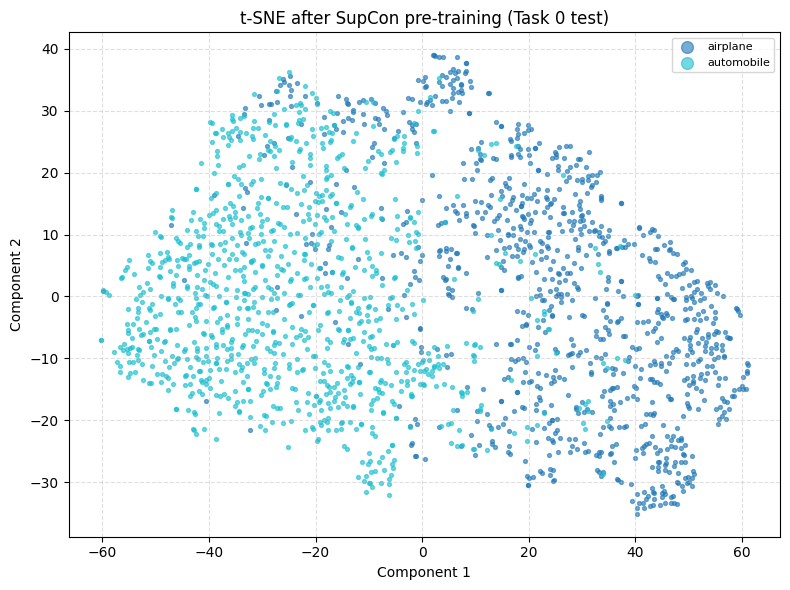

In [12]:
import numpy as np
from evaluation.visualization import plot_embeddings
from data.cifar10_tasks import CIFAR10_CLASSES, TASK_CLASSES


def extract_embeddings(backbone, loader, device):
    """Extract backbone features for all examples in *loader*."""
    backbone.eval()
    all_feats, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            imgs, _, global_labels = batch
            feats = backbone(imgs.to(device))
            all_feats.append(feats.cpu().numpy())
            all_labels.append(global_labels.numpy())
    return np.concatenate(all_feats), np.concatenate(all_labels)


task0_test = DataLoader(tasks.get_test(0), batch_size=256, shuffle=False)
feats, labels = extract_embeddings(backbone, task0_test, DEVICE)

class_names = [CIFAR10_CLASSES[c] for c in TASK_CLASSES[0]]
fig = plot_embeddings(
    feats, labels,
    class_names=CIFAR10_CLASSES,
    method='tsne',
    title='t-SNE after SupCon pre-training (Task 0 test)',
    save_path=str(IMGS_DIR / 'tsne_after_pretrain.png')
)
fig.show()

In [13]:
import torch.nn as nn
import torch.optim as optim

# Linear probe on frozen backbone.
backbone.freeze()
linear_head = LinearHead(in_dim=512, num_classes=2).to(DEVICE)
optimizer = optim.Adam(linear_head.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

task0_train_plain = DataLoader(tasks.get_train(0), batch_size=256, shuffle=True, num_workers=2)

EPOCHS_LINEAR = 20
for epoch in range(EPOCHS_LINEAR):
    linear_head.train()
    for imgs, local_labels, _ in task0_train_plain:
        imgs, local_labels = imgs.to(DEVICE), local_labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.no_grad():
            feats = backbone(imgs)
        loss = criterion(linear_head(feats), local_labels)
        loss.backward()
        optimizer.step()

# Evaluate.
linear_head.eval()
correct, total = 0, 0
for imgs, local_labels, _ in task0_test:
    imgs, local_labels = imgs.to(DEVICE), local_labels.to(DEVICE)
    with torch.no_grad():
        feats  = backbone(imgs)
        preds  = linear_head(feats).argmax(dim=1)
    correct += (preds == local_labels).sum().item()
    total   += imgs.size(0)

print(f'Task 0 linear probe accuracy: {correct/total:.4f}')

Task 0 linear probe accuracy: 0.8770
